Далее "control" группа со старой лентой без ключевых характеристик, "treatment" с новой лентой с ключевыми характеристиками.

In [1]:
import pandas as pd
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

In [2]:
baseline_rate = 0.22

effect_size = 0.22
mde_rate = 0.25

effect_size = proportion_effectsize(baseline_rate, mde_rate)

analysis = NormalIndPower()
sample_size = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.8,
    ratio=1.0
)

sample_size = round(sample_size)
print(f"Нужно пользователей на группу: {sample_size}")
print(f"Итого на тест: {sample_size*2}")

Нужно пользователей на группу: 3133
Итого на тест: 6266


# Пояснения к вычислению размера выборки

Рост конверсии берётся $\ge x$ п.п., так как при значениях меньше, затраты превышают прибыль от продукта. В нашем случае $x = 3$.

При определённом MDE можно посчитать нужный размер выборки и длительность теста.

In [3]:
df = pd.read_csv("../data/ab_test_dataset.csv")
df = df.sample(frac=1, random_state=42, ignore_index=True)
control_df = df[df["group"] == "control"].head(sample_size).reset_index(drop=True)
treatment_df = df[df["group"] == "treatment"].head(sample_size).reset_index(drop=True)
sample_size_df = pd.concat([control_df, treatment_df], axis=0, ignore_index=True)

control_ACV = df[df["group"]=="control"]["ACV_col"].head(sample_size)
treatment_ACV = df[df["group"]=="treatment"]["ACV_col"].head(sample_size)

In [4]:
summary = sample_size_df.groupby("group")["converted"].agg(["count", "sum", "mean"]).rename(
    columns={"count": "total_users", "sum": "conversions", "mean": "conversion_rate"}
)
print(summary)

           total_users  conversions  conversion_rate
group                                               
control           3133          677         0.216087
treatment         3133          772         0.246409


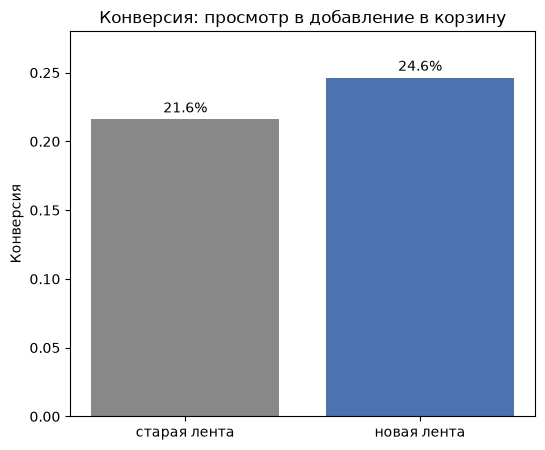

In [5]:
rates = summary['conversion_rate']
plt.figure(figsize=(6,5))
plt.bar(["старая лента", "новая лента"], rates.values, color=['#888888', '#4C72B0'])
plt.ylim(0, 0.28)
plt.ylabel('Конверсия')
plt.title('Конверсия: просмотр в добавление в корзину')
for i, v in enumerate(rates.values):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center')
plt.savefig('../images/view_by_cart.png', dpi=150)
plt.show()

In [6]:
count = [summary.loc["treatment", "conversions"], summary.loc["control", "conversions"]]
nobs = [summary.loc["treatment", "total_users"], summary.loc["control", "total_users"]]

z_stat, p_value = proportions_ztest(count, nobs)
print(f"z-статистика: {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")

z-статистика: 2.846
p-value: 0.0044


In [7]:
ci_low, ci_upp = confint_proportions_2indep(
    count1=summary.loc["treatment", "conversions"], nobs1=summary.loc["treatment", "total_users"],
    count2=summary.loc["control", "conversions"], nobs2=summary.loc["control", "total_users"]
)
print(f"95% доверительный интервал разности конверсий: [{ci_low:.4f}, {ci_upp:.4f}]")

95% доверительный интервал разности конверсий: [0.0094, 0.0512]


In [8]:
t_stat_ACV, p_value_ACV = ttest_ind(control_ACV, treatment_ACV, equal_var=False)
print(f"t-статистика ACV: {t_stat_ACV:.3f}, p-value ACV: {p_value_ACV:.4f}")

t-статистика ACV: -0.949, p-value ACV: 0.3426


# Пояснения к тестированию полученных метрик

Для начала тестируем основную метрику: конверсию. Используем z-test, так как метрика бинарная, из него получаем p-value, в нашем случае < 0.05, что позволяет отклонить нулевую гипотезу и принять альтернативную, дополнительно получаем доверительный интервал разности конверсий, он поможет оценить размер различий между группами.

Теперь оценим guardrail метрику: ACV. Тестируем ACV при помощи t-теста, так как метрика непрерывное число, получаем p-value < 0.05, то есть это метрика статистически значимо не изменилась. Если бы эта guardrail статистически значимо ухудшилась (в данном случае уменьшилась), то однозначно рекомендовать бы продукт группы B было бы нельзя, даже при статистически значимом улучшении целевой метрики.

In [9]:
for plat in df["platform"].unique():
    sub = df[df["platform"] == plat].head(sample_size)
    sub_summary = sub.groupby("group")["converted"].agg(["count", "sum"])
    count = [sub_summary.loc["control", "sum"], sub_summary.loc["treatment", "sum"]]
    nobs = [sub_summary.loc["control", "count"], sub_summary.loc["treatment", "count"]]
    z_stat, p_value = proportions_ztest(count, nobs)
    print(f"{plat}: p-value = {p_value:.4f}")

ios: p-value = 0.0105
web: p-value = 0.0795
android: p-value = 0.1410


# Пояснения к сегментному анализу

A/B-тест групп между сегментами "platform" при помощи z-test. Видно, что p-value в web и android > 0.05.

Сегментный анализ здесь носит исследовательский характер, не подтверждающий, так как при множественных сравнениях получить значимое различие, при его реальном отсутствии, сильно возрастает, для корректности теста надо брать поправку для порога значимости или p-value, например поправку Бонферрони.